In [1]:
"""
from google.colab import drive
drive.mount('/content/drive')
"""

"\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

In [2]:
#from unet_model_with_functions_of_blocks import build_unet
import os
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

#New generator with rotation and shear where interpolation that comes with rotation and shear are thresholded in masks.
#This gives a binary mask rather than a mask with interpolated values.
seed=24
batch_size= 8
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
#####################################################################
#Define the model. Experiment with various loss functions and accuracy metrics
# pip install focal-loss

#######################################


#Jaccard distance loss mimics IoU.
#from keras import backend as K
import tensorflow.keras.backend as K
def jaccard_distance_loss(y_true, y_pred, smooth=100):
    """
    Jaccard = (|X & Y|)/ (|X|+ |Y| - |X & Y|)
            = sum(|A*B|)/(sum(|A|)+sum(|B|)-sum(|A*B|))

    The jaccard distance loss is usefull for unbalanced datasets. This has been
    shifted so it converges on 0 and is smoothed to avoid exploding or disapearing
    gradient.

    Ref: https://en.wikipedia.org/wiki/Jaccard_index

    @url: https://gist.github.com/wassname/f1452b748efcbeb4cb9b1d059dce6f96
    @author: wassname
    """
    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))
    sum_ = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return (1 - jac) * smooth

#Dice metric can be a great metric to track accuracy of semantic segmentation.
def dice_metric(y_pred, y_true):
    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))
    union = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))
    # if y_pred.sum() == 0 and y_pred.sum() == 0:
    #     return 1.0

    return 2*intersection / union





In [4]:
import os
#os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input

from tensorflow.keras.layers import AveragePooling2D, GlobalAveragePooling2D, UpSampling2D, Reshape, Dense

from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
import tensorflow as tf

In [5]:
def SqueezeAndExcite(inputs, ratio=8):
    init = inputs
    filters = init.shape[-1]
    se_shape = (1, 1, filters)

    se = GlobalAveragePooling2D()(init)
    se = Reshape(se_shape)(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    x = init * se
    return x

In [6]:
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import UpSampling2D, Conv2D, Activation, BatchNormalization, Concatenate, AveragePooling2D
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50
import keras
img_size = (224, 224)
num_classes = 1



from tensorflow.keras import layers



from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50



def decoder_block(x, y, filters):
    x = UpSampling2D()(x)
    x = Concatenate(axis = 3)([x,y])
    x = Conv2D(filters, 3, padding= 'same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Conv2D(filters, 3, padding= 'same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    return x

def resnet50_unet(input_shape, *, classes, dropout):
    """ Input """
    inputs = Input(input_shape)

    resnet50 = ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)

    """ Encoder """
    s1 = resnet50.get_layer("input_1").output          
    s2 = resnet50.get_layer("conv1_relu").output       
    s3 = resnet50.get_layer("conv2_block3_out").output 
    s4 = resnet50.get_layer("conv3_block4_out").output  

    x = resnet50.get_layer("conv4_block6_out").output  

    """ Decoder """
    x = decoder_block(x, s4, 512)                     
    x = decoder_block(x, s3, 256)                    
    x = decoder_block(x, s2, 128)                    
    x = decoder_block(x, s1, 64)                      

    x = Dropout(dropout)(x)
    outputs = Conv2D(classes, 1, activation="sigmoid")(x)

    model = Model(inputs, outputs, name="ResNet50_U-Net")
    return model

if __name__ == "__main__":
    model = resnet50_unet((224, 224, 3), classes= 1, dropout= 0.2)
    model.summary()

Model: "ResNet50_U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                     

                                                                                                  
 conv4_block2_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_2_conv[0][0]']    
 ization) 

 conv4_block5_1_conv (Conv2D)   (None, 14, 14, 256)  262400      ['conv4_block4_out[0][0]']       
                                                                                                  
 conv4_block5_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block5_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block5_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block5_1_relu[0][0]']    
                                                                                                  
 conv4_blo

 batch_normalization_2 (BatchNo  (None, 56, 56, 256)  1024       ['conv2d_2[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 leaky_re_lu_2 (LeakyReLU)      (None, 56, 56, 256)  0           ['batch_normalization_2[0][0]']  
                                                                                                  
 conv2d_3 (Conv2D)              (None, 56, 56, 256)  590080      ['leaky_re_lu_2[0][0]']          
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 56, 56, 256)  1024       ['conv2d_3[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 leaky_re_

In [7]:
"""
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import UpSampling2D, Conv2D, Activation, BatchNormalization, Concatenate, AveragePooling2D
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50
import keras


def ASPP(inputs):

    #shape = inputs.shape
    #y1 = AveragePooling2D(pool_size=(shape[1], shape[2]))(inputs)
    #y1 = Conv2D(256, 1, padding="same", use_bias=False)(y1)
    #y1 = BatchNormalization()(y1)
    #y1 = Activation("relu")(y1)
    #y1 = UpSampling2D((shape[1], shape[2]), interpolation="bilinear")(y1)


    y2 = Conv2D(256, 1, padding="same", use_bias=False)(inputs)
    y2 = BatchNormalization()(y2)
    y2 = Activation("relu")(y2)


    y3 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=6)(inputs)
    y3 = BatchNormalization()(y3)
    y3 = Activation("relu")(y3)


    y4 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=12)(inputs)
    y4 = BatchNormalization()(y4)
    y4 = Activation("relu")(y4)


    y5 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=18)(inputs)
    y5 = BatchNormalization()(y5)
    y5 = Activation("relu")(y5)


    y1 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=24)(inputs)
    y1 = BatchNormalization()(y1)
    y1 = Activation("relu")(y1)

    y = Concatenate()([y1, y2, y3, y4, y5])
    y = Conv2D(256, 1, padding="same", use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Activation("relu")(y)

    return y


def deeplabv3_plus(shape):

    inputs = Input(shape)


    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
    #base_model = keras.applications.EfficientNetV2L(weights='imagenet', include_top=False, input_tensor=inputs)
    base_model.summary()
    image_features = base_model.get_layer('conv4_block6_out').output
    print(image_features.shape,"image_features")
    x_a = ASPP(image_features)
    x_a = UpSampling2D((4, 4), interpolation="bilinear")(x_a)

    x_b = base_model.get_layer('conv2_block2_out').output
    print(x_b.shape,"x_b")
    x_b = Conv2D(filters=48, kernel_size=1, padding='same', use_bias=False)(x_b)
    x_b = BatchNormalization()(x_b)
    x_b = Activation('relu')(x_b)

    x = Concatenate()([x_a, x_b])
    x = SqueezeAndExcite(x)

    x = Conv2D(filters=256, kernel_size=3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters=256, kernel_size=3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SqueezeAndExcite(x)

    x = UpSampling2D((4, 4), interpolation="bilinear")(x)
    x = Conv2D(1, 1)(x)
    x = Activation("sigmoid")(x)

    model = Model(inputs, x)
    return model
H,W=224,224
model = deeplabv3_plus((H, W, 3))
"""

'\nfrom tensorflow.keras import layers, Model\nfrom tensorflow.keras.layers import UpSampling2D, Conv2D, Activation, BatchNormalization, Concatenate, AveragePooling2D\nfrom tensorflow.keras.applications import MobileNet\nfrom tensorflow.keras.regularizers import l2\nfrom tensorflow.keras.applications import ResNet50\nimport keras\n\n\ndef ASPP(inputs):\n\n    #shape = inputs.shape\n    #y1 = AveragePooling2D(pool_size=(shape[1], shape[2]))(inputs)\n    #y1 = Conv2D(256, 1, padding="same", use_bias=False)(y1)\n    #y1 = BatchNormalization()(y1)\n    #y1 = Activation("relu")(y1)\n    #y1 = UpSampling2D((shape[1], shape[2]), interpolation="bilinear")(y1)\n\n\n    y2 = Conv2D(256, 1, padding="same", use_bias=False)(inputs)\n    y2 = BatchNormalization()(y2)\n    y2 = Activation("relu")(y2)\n\n\n    y3 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=6)(inputs)\n    y3 = BatchNormalization()(y3)\n    y3 = Activation("relu")(y3)\n\n\n    y4 = Conv2D(256, 3, padding="same", use_

In [8]:
import os
#os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import cv2
from glob import glob
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision
#from metrics import dice_loss, dice_coef, iou

In [9]:
"""
def dice_metric(y_pred, y_true):
    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))
    union = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))
    # if y_pred.sum() == 0 and y_pred.sum() == 0:
    #     return 1.0

    return 2*intersection / union
"""

'\ndef dice_metric(y_pred, y_true):\n    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))\n    union = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))\n    # if y_pred.sum() == 0 and y_pred.sum() == 0:\n    #     return 1.0\n\n    return 2*intersection / union\n'

In [10]:
"""
from keras import backend as K
def jaccard_distance_loss(y_true, y_pred, smooth=100):

    Jaccard = (|X & Y|)/ (|X|+ |Y| - |X & Y|)
            = sum(|A*B|)/(sum(|A|)+sum(|B|)-sum(|A*B|))

    The jaccard distance loss is usefull for unbalanced datasets. This has been
    shifted so it converges on 0 and is smoothed to avoid exploding or disapearing
    gradient.

    Ref: https://en.wikipedia.org/wiki/Jaccard_index

    @url: https://gist.github.com/wassname/f1452b748efcbeb4cb9b1d059dce6f96
    @author: wassname

    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))
    sum_ = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return (1 - jac) * smooth
"""

'\nfrom keras import backend as K\ndef jaccard_distance_loss(y_true, y_pred, smooth=100):\n\n    Jaccard = (|X & Y|)/ (|X|+ |Y| - |X & Y|)\n            = sum(|A*B|)/(sum(|A|)+sum(|B|)-sum(|A*B|))\n\n    The jaccard distance loss is usefull for unbalanced datasets. This has been\n    shifted so it converges on 0 and is smoothed to avoid exploding or disapearing\n    gradient.\n\n    Ref: https://en.wikipedia.org/wiki/Jaccard_index\n\n    @url: https://gist.github.com/wassname/f1452b748efcbeb4cb9b1d059dce6f96\n    @author: wassname\n\n    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))\n    sum_ = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))\n    jac = (intersection + smooth) / (sum_ - intersection + smooth)\n    return (1 - jac) * smooth\n'

In [11]:

metrics = ["accuracy",
           tf.keras.metrics.AUC(),
           tf.keras.metrics.SensitivityAtSpecificity(0.5),
           tf.keras.metrics.SpecificityAtSensitivity(0.5),
          dice_metric,
          jaccard_distance_loss]
model.compile(loss="binary_crossentropy", optimizer=Adam(1e-4), metrics=metrics)

In [12]:
callbacks = [
    EarlyStopping(patience=10, verbose=1),
    ReduceLROnPlateau(factor=0.1, patience=5, min_lr=0.00001, verbose=1),
   tf.keras.callbacks.ModelCheckpoint(
    'wholemodel.keras',
    monitor='val_loss',
    verbose=0,
    save_best_only=False,
    #save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
),
    CSVLogger("dataResUnet.csv"),
    TensorBoard(log_dir='./logs')
]

In [13]:
import os
batch_size=8

num_train_imgs = len(os.listdir("C:\\recent caltech\\journal 2 GA for segmentation\\original split\\all images\\train images\\train"))

steps_per_epoch1 = num_train_imgs //batch_size
print(steps_per_epoch1)

num_train_imgs1 = len(os.listdir("C:\\recent caltech\\journal 2 GA for segmentation\\original split\\output splitted\\test\\images\\images\\"))

steps_per_epoch2 = num_train_imgs1 //batch_size
print(steps_per_epoch2)

749
362


In [14]:
img_height,img_width=224,224
#from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator


input_imgen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   rotation_range=5.,
                                   horizontal_flip = True)

test_imgen = ImageDataGenerator(rescale = 1./255)



def generate_generator_multiple(generator,dir1, dir4,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False,
                                          seed=7)

    genY1 = generator.flow_from_directory(dir4,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          color_mode='grayscale',
                                          shuffle=False,
                                          seed=7)
    while True:
            X1i = genX1.__next__()

            XYi = genY1.__next__()
            yield X1i, XYi  #Yield both images and their mutual label

def generate_generator_testing(generator,dir1,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False,
                                          seed=7)



    while True:
            X1i = genX1.__next__()
            #XYi = genY1.next()
            yield X1i  #Yield both images and their mutual label


In [15]:
batch_size=8
img_height=224
img_width=224

inputgenerator=generate_generator_multiple(generator=input_imgen,
                                           dir1="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\all images\\train images",
                                           
                                           dir4="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\all masks\\train masks",
                                           
                                           batch_size=batch_size,
                                           img_height=img_height,
                                           color_mode='grayscale',
                                           img_width=img_width)       
     
valgenerator=generate_generator_multiple(generator=test_imgen,
                                          dir1="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\output splitted\\test\\images\\",
                                        
                                          dir4="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\output splitted\\test\\masks\\",
                                          batch_size=batch_size,
                                          color_mode='grayscale',
                                          img_height=img_height,
                                          img_width=img_width)              
 

In [16]:
callbacks = [EarlyStopping(monitor='val_loss' , patience=5 , restore_best_weights=True)]

In [17]:
results=model.fit(inputgenerator,
                        steps_per_epoch=steps_per_epoch1,
                        epochs =20,
                        validation_data = valgenerator,
                        validation_steps = steps_per_epoch2,
                        callbacks=callbacks ,
                        #use_multiprocessing=True,
                        #shuffle=False
                           )

Found 5994 images belonging to 1 classes.
Found 5994 images belonging to 1 classes.
Epoch 1/20
749/749 [==============================] - ETA: 0s - loss: 0.1626 - accuracy: 0.9090 - auc: 0.9448 - sensitivity_at_specificity: 0.9632 - specificity_at_sensitivity: 0.9984 - dice_metric: 0.6748 - jaccard_distance_loss: 48.5114Found 2897 images belonging to 1 classes.
Found 2897 images belonging to 1 classes.
749/749 [==============================] - 331s 395ms/step - loss: 0.1626 - accuracy: 0.9090 - auc: 0.9448 - sensitivity_at_specificity: 0.9632 - specificity_at_sensitivity: 0.9984 - dice_metric: 0.6748 - jaccard_distance_loss: 48.5114 - val_loss: 0.1257 - val_accuracy: 0.9225 - val_auc: 0.9721 - val_sensitivity_at_specificity: 0.9860 - val_specificity_at_sensitivity: 0.9991 - val_dice_metric: 0.7014 - val_jaccard_distance_loss: 45.6136
Epoch 2/20
749/749 [==============================] - 297s 393ms/step - loss: 0.1049 - accuracy: 0.9188 - auc: 0.9657 - sensitivity_at_specificity: 0.978

In [18]:
import pandas as pd
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,accuracy,auc,sensitivity_at_specificity,specificity_at_sensitivity,dice_metric,jaccard_distance_loss,val_loss,val_accuracy,val_auc,val_sensitivity_at_specificity,val_specificity_at_sensitivity,val_dice_metric,val_jaccard_distance_loss
6,0.069623,0.924479,0.982716,0.984431,0.999942,0.854922,25.180807,0.069213,0.937116,0.981783,0.978983,0.999987,0.858504,24.635685
8,0.066823,0.925343,0.983981,0.984342,0.999952,0.860165,24.379299,0.071381,0.936178,0.982432,0.982224,0.999945,0.854386,25.256561
10,0.066738,0.924768,0.984137,0.984238,0.999966,0.861580,24.154282,0.071493,0.936468,0.982342,0.980650,0.999943,0.849031,26.055988
7,0.068316,0.924838,0.983403,0.984172,0.999937,0.857875,24.727955,0.074135,0.935961,0.981196,0.979697,0.999934,0.854572,25.220705
3,0.080078,0.922889,0.977554,0.978608,0.999881,0.831561,28.636337,0.075885,0.935859,0.982296,0.984288,0.999937,0.844136,26.790842
5,0.073896,0.923322,0.980854,0.985063,0.999901,0.846431,26.444281,0.076881,0.934380,0.979850,0.979058,0.999843,0.837127,27.816822
11,0.063716,0.925802,0.985511,0.985275,0.999983,0.866969,23.327143,0.077951,0.935443,0.976666,0.967869,0.999920,0.856734,24.862013
9,0.067054,0.924727,0.984023,0.984175,0.999967,0.860618,24.300247,0.078087,0.934858,0.981843,0.982726,0.999600,0.854816,25.152060
4,0.074884,0.923461,0.980023,0.986235,0.999921,0.843392,26.902601,0.078328,0.934396,0.979164,0.977531,0.999891,0.839241,27.490627
1,0.104910,0.918839,0.965695,0.978536,0.999598,0.775858,36.341442,0.093358,0.930888,0.977361,0.985444,0.999753,0.796896,33.538857


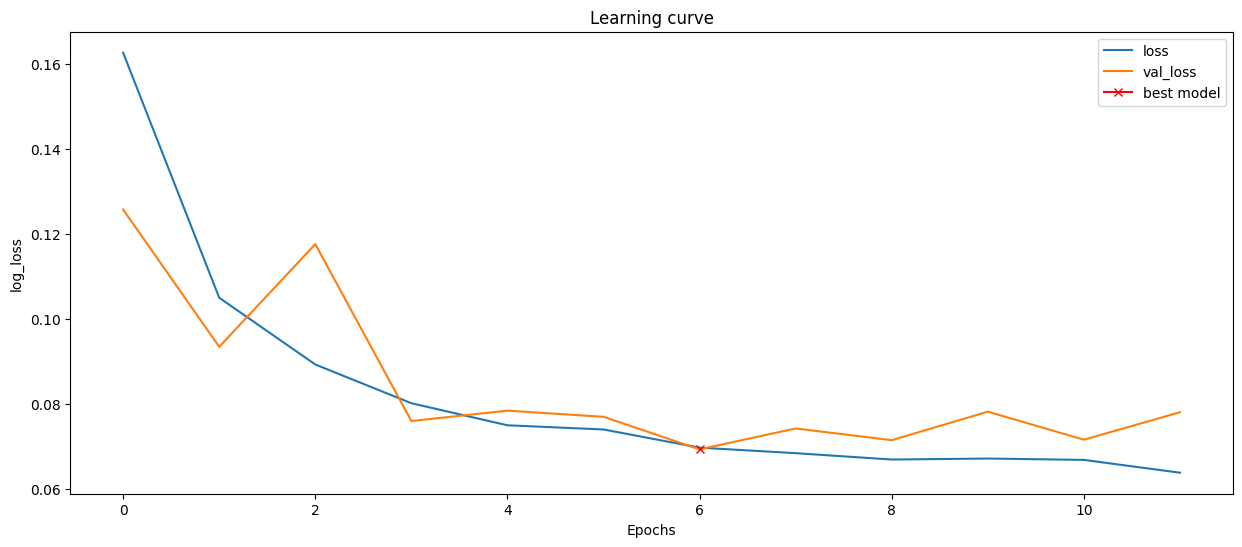

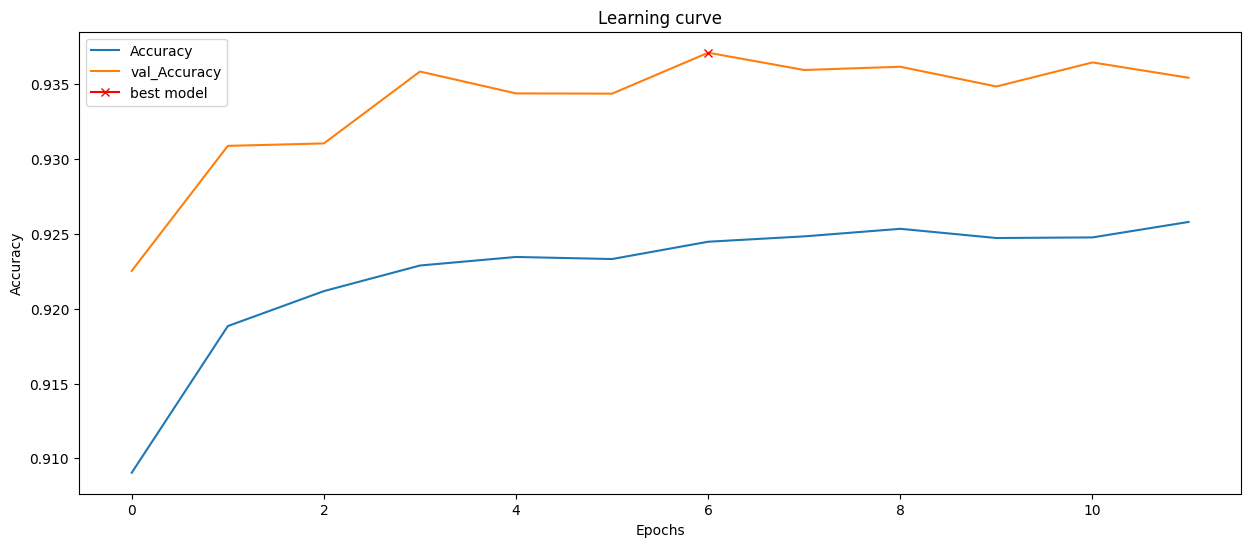

In [19]:

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="loss")
plt.plot(results.history["val_loss"], label="val_loss")
plt.plot(np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["accuracy"], label="Accuracy")
plt.plot(results.history["val_accuracy"], label="val_Accuracy")
plt.plot(np.argmax(results.history["val_accuracy"]), np.max(results.history["val_accuracy"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();


In [20]:
"""
valid_img_generator = image_data_generator.flow_from_directory("C:\\recent caltech\\deeplabv3+ hirarchical clustering\\deeplabv3+ oneshot\\val image\\",
                                                               seed=seed,
                                                               target_size=(224,224),
                                                               batch_size=batch_size,
                                                               class_mode=None) #Default batch size 32, if not specified here

"""

'\nvalid_img_generator = image_data_generator.flow_from_directory("C:\\recent caltech\\deeplabv3+ hirarchical clustering\\deeplabv3+ oneshot\\val image\\",\n                                                               seed=seed,\n                                                               target_size=(224,224),\n                                                               batch_size=batch_size,\n                                                               class_mode=None) #Default batch size 32, if not specified here\n\n'

In [21]:
model.save('Unet.h5')

In [ ]:
generator = ImageDataGenerator(rescale = 1./255)

dir1="C:\\recent caltech\\deeplab3++\\big data 90 10\\test images\\"
genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size =1,
                                          shuffle=False,
                                          seed=seed)
model.save('oneshotdeeplab.hdf5')
for i in range(30):
    #img, label = dir_It.next()
    img1=genX1.next()
    print(img1.shape)   #  (1,256,256,3)
    predict = model.predict(img1)
    x=predict[0]
    plt.imshow(x)
    #plt.show
    plt.savefig('C:\\recent caltech\\deeplab3++\\testing\\predicted\\'+str(i)+'.png')
    plt.imshow(img1[0])
    plt.savefig('C:\\recent caltech\\deeplab3++\\testing\\original\\'+str(i)+'png')
    #plt.imshow(img[0])
    #plt.show()

"""
genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = 32,
                                          shuffle=False,
                                          seed=7)
X1i = genX1.next()
"""

In [ ]:
#predict = model.predict(valid_img_generator,steps =1179)

In [ ]:
"""from PIL import Image
for i in range(len(predict)):
    x=predict[i]
    plt.imshow(x)
    #plt.show
    plt.savefig('C:\\recent caltech\\deeplab3++\\verification\\New folder\\new changes\\new_existing_images\\'+str(i)+'.png')
    #img = Image.fromarray(arr[i], 'RGB')
    #plt.imsave('C:\\recent caltech\\deeplab3++\\verification\\part2_images\\'+str(i)+'.png', img)
"""

In [ ]:
model.save('raw_mobilenet.hdf5')

In [ ]:
print(seed)

24


In [ ]:
def generate_generator_multiple(generator,dir1, dir4,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False,
                                          seed=7)

    genY1 = generator.flow_from_directory(dir4,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          color_mode='grayscale',
                                          shuffle=False,
                                          seed=7)
    while True:
            X1i = genX1.next()

            XYi = genY1.next()
            yield X1i, XYi

def generate_generator_testing(generator,dir1,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False,
                                          seed=7)



    while True:
            X1i = genX1.next()
            #XYi = genY1.next()
            yield X1i

In [ ]:
testgenerator=generate_generator_multiple(generator=test_imgen,
                                          dir1="C:\\recent caltech\\deeplab3++\\big data 90 10\\val images\\",

                                          dir4="C:\\recent caltech\\deeplab3++\\big data 90 10\\val masks\\",
                                          batch_size=32,
                                          color_mode='grayscale',
                                          img_height=img_height,
                                          img_width=img_width)

In [ ]:
batch_size=32
num_train_imgs1 = len(os.listdir("C:\\recent caltech\\deeplab3++\\big data 90 10\\val images\\val\\"))

steps_per_epochz = num_train_imgs1 //batch_size
print(steps_per_epochz)

18


In [ ]:
metrics1 =model.evaluate(testgenerator,steps=18)
print('Test loss:', metrics1[0])
print('Test accuracy:', metrics1[1])

18/18 [==============================] - 5s 253ms/step - loss: 0.0632 - accuracy: 0.9386 - auc: 0.9853 - sensitivity_at_specificity: 0.9845 - specificity_at_sensitivity: 1.0000 - dice_metric: 0.8685 - jaccard_distance_loss: 23.2001
Test loss: 0.06319846957921982
Test accuracy: 0.938551664352417


In [ ]:
loss, accuracy = model.evaluate_generator(testgenerator, steps=len(testgenerator))
print('Test loss:', loss)
print('Test accuracy:', accuracy)

TypeError: object of type 'generator' has no len()